# Hantavirus Sentiment and Topic Analysis 
This code will complete overall sentiment and topic analysis for bluesky data on the hantavirus 

---
### Libraries & Data

In [6]:
#Libraries to be imported
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import sys
import string
import re
import nltk
import codecs
import emoji
import gensim
import random
import numpy as np
from datetime import datetime, date, timedelta
from collections import Counter
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer 
from nltk import bigrams
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import DetectorFactory
from gensim.models import CoherenceModel
from gensim.models import LdaModel
from wordcloud import WordCloud
from gensim import corpora
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /Users/hazelkok/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [7]:
df = pd.read_csv("./Data/Bluesky_dataset_UG11.csv")

In [8]:
df['created_at'] = pd.to_datetime(
    df['created_at'],
    format='ISO8601'
)

/var/folders/rt/ntympq6n43582kgy0p0xxpc00000gn/T/ipykernel_92838/174515691.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['created_at'] = pd.to_datetime(


In [9]:
hanta_posts = []

for row in df.itertuples(index=False):
    post_author = row.author
    post_text = row.text
    post_date = row.created_at
    post_likes = row.likes
    post_reposts = row.reposts

    hanta_posts.append([post_author, post_text, post_date, post_likes, post_reposts])

print(hanta_posts)

[['yourcanadiangf.bsky.social', "did he do Elon's botched Dong implant?", Timestamp('2026-05-15 16:15:34.751000+0000', tz='UTC'), 0, 0], ['fluffythecruel.bsky.social', 'I’m at the penile implant specialist. I’m at the hantavirus presser. I’m at the combination penile implant and hantavirus presser.', Timestamp('2026-05-15 11:08:07.165000+0000', tz='UTC'), 3, 0], ['marcosantana.bsky.social', 'A twofer', Timestamp('2026-05-15 12:44:58.919000+0000', tz='UTC'), 0, 0], ['marcosantana.bsky.social', 'A twofer.', Timestamp('2026-05-15 12:44:00.948000+0000', tz='UTC'), 0, 0], ['twinsfan81.bsky.social', 'They are trying to kill all of us, aren’t they.', Timestamp('2026-05-15 14:15:38.513000+0000', tz='UTC'), 1, 0], ['mrfuzzyfart.bsky.social', 'They only put the best and brightest in charge (sarc)', Timestamp('2026-05-15 16:04:22.584000+0000', tz='UTC'), 1, 0], ['idontnou.bsky.social', "Well, they're all dick specialists.", Timestamp('2026-05-15 14:39:29.334000+0000', tz='UTC'), 0, 0], ['muralgob

In [10]:
len(hanta_posts)

14451

In [11]:
#Code adapted from: https://medium.com/@monigrancharov/text-language-detection-with-python-beb49d9667b3 & https://pypi.org/project/langdetect/
#Method to detect the langauge of the comments
def detect_language_analysis(text): 
    try: 
        language = detect(text) 
        return language #Return language if detected

    except: return "Unknown" #Return unknown if language not known - example small sentances

In [12]:
#Get a count for each language in the dataset
#To be put into a table in the final report
language_count = Counter() #Set up a counter to count all the languages
Lan_date = [] #List to hold the date of the comments
English_posts = [] #List of English comments - to be used for rest of analysis
DetectorFactory.seed = 0 #Detecting languages can give different results, we set a seed to ensure consistency when code is run again

#Detecting the languages from the comments
for post_author, post_text, post_date, post_likes, post_reposts in hanta_posts:
    language = detect_language_analysis(post_text)
    language_count.update([language]) #Update the counter with language
    Lan_date.append([post_date, language]) #Append date and language to Lan_date
    if language == 'en':
        English_posts.append([post_author, post_date, post_text, post_likes, post_reposts]) #Only if the language is English append to the english list

language_count #Print the count of languages to be used in table in report

Counter({'en': 14387,
         'cy': 9,
         'fr': 7,
         'de': 6,
         'af': 5,
         'tl': 4,
         'nl': 4,
         'cs': 3,
         'et': 3,
         'sv': 2,
         'so': 2,
         'it': 2,
         'fi': 2,
         'id': 2,
         'pl': 2,
         'ca': 2,
         'da': 2,
         'es': 1,
         'no': 1,
         'ro': 1,
         'sl': 1,
         'pt': 1,
         'sk': 1,
         'sq': 1})

In [13]:
#Code adapted from Week 3/4 Workshop code (data processing)
#Code adapted from https://stackoverflow.com/questions/15586721/wordnet-lemmatization-and-pos-tagging-in-python (POS tagging approach to Lemmas)

#Method to process text for N-Grams analysis
def processText(text, tokenizer, Lemma, stopwords):

    #Method to pos tagging words to improve lemmatization
    def get_wordnet_pos(treebank_tag):

        if treebank_tag.startswith('J'):
            return wordnet.ADJ
        elif treebank_tag.startswith('V'):
            return wordnet.VERB
        elif treebank_tag.startswith('N'):
            return wordnet.NOUN
        elif treebank_tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.VERB

    #Convert all to lower case
    text = text.lower()

    #Tokenise
    lTokens = tokenizer.tokenize(text) 
    #Strip whitespaces before and after
    lTokens = [token.strip() for token in lTokens]

     #POS tagging
    pos_tag_token = nltk.pos_tag(lTokens)

    #Lemmatization
    lStemmedTokens = [Lemma.lemmatize(tok, get_wordnet_pos(tag)) for tok, tag in pos_tag_token]

    #Remove stopwords, digits, emojis
    return [tok for tok in lStemmedTokens if tok not in stopwords and tok.isalpha()]

#Number of most frequent terms to display
freqNum = 50

#Tokeniser (TweetTokenizer works well for social media text in general)
tweetTokeniser = nltk.tokenize.TweetTokenizer()
#Punctuation list
lPunct = list(string.punctuation)
#Stopwords
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['via']
#Lemmatizer
lemmatizer = WordNetLemmatizer()
#Term frequency counter
termFreqCounter = Counter()
SB_token_comments = []

#Process each english comment
for post_author, post_date, post_text, post_likes, post_reposts in English_posts:
    #Filter out unicode characters (optional but keep for consistency)
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)

    #Process text
    lTokens = processText(
        text=post_text,
        tokenizer=tweetTokeniser,
        Lemma=lemmatizer,
        stopwords=lStopwords
    )

    #Update term frequency
    termFreqCounter.update(lTokens)
    SB_token_comments.append(lTokens) 

In [14]:
#Print Unigram term frequencies
termFreqCounter 

Counter({'hantavirus': 2298,
         'ship': 1713,
         'cruise': 1640,
         'people': 1486,
         'get': 1115,
         'outbreak': 1108,
         'go': 1082,
         'like': 1048,
         'covid': 958,
         'know': 947,
         'say': 927,
         'one': 918,
         'virus': 906,
         'us': 728,
         'think': 723,
         'would': 678,
         'spread': 676,
         'health': 673,
         'trump': 654,
         'passenger': 632,
         'time': 598,
         'case': 542,
         'take': 530,
         'make': 528,
         'quarantine': 516,
         'human': 509,
         'good': 506,
         'need': 485,
         'pandemic': 459,
         'see': 450,
         'thing': 447,
         'news': 438,
         'contact': 437,
         'public': 424,
         'cdc': 424,
         'also': 423,
         'disease': 415,
         'well': 412,
         'person': 410,
         'could': 404,
         'day': 384,
         'right': 380,
         'die': 374,
     

In [15]:
#Code adapted from: https://www.geeksforgeeks.org/nlp/generate-bigrams-with-nltk/
biFreqCounter = Counter() #Counter for Bigrams
Bi_gram_comments = [] #List to hold Bigram comments

#Get all bigrams and append to counter and list
for comment in SB_token_comments:
    comment_bigrams = list(bigrams(comment))
    Bi_gram_comments.append(comment_bigrams)
    biFreqCounter.update(comment_bigrams)

#Print Bigram term frequencies
biFreqCounter 

Counter({('cruise', 'ship'): 1050,
         ('hantavirus', 'outbreak'): 471,
         ('public', 'health'): 261,
         ('rfk', 'jr'): 223,
         ('human', 'human'): 156,
         ('mv', 'hondius'): 139,
         ('test', 'positive'): 134,
         ('hantavirus', 'cruise'): 132,
         ('incubation', 'period'): 115,
         ('close', 'contact'): 109,
         ('andes', 'virus'): 102,
         ('go', 'cruise'): 90,
         ('person', 'person'): 88,
         ('penile', 'implant'): 82,
         ('sound', 'like'): 82,
         ('look', 'like'): 82,
         ('petri', 'dish'): 82,
         ('infectious', 'disease'): 78,
         ('andes', 'strain'): 78,
         ('andes', 'hantavirus'): 75,
         ('like', 'covid'): 73,
         ('people', 'die'): 72,
         ('outbreak', 'cruise'): 69,
         ('trump', 'administration'): 66,
         ('health', 'official'): 65,
         ('ship', 'outbreak'): 64,
         ('go', 'wrong'): 61,
         ('wear', 'mask'): 58,
         ('get', 'si

In [16]:
# ── Light clean for VADER (keep full sentences) ──────────────────────
def clean_for_sentiment(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# ── YouTube-style processText (replaces processTextSA) ───────────────
def processTextSA(text, tokenizer, stopwords):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    tokens = [token.strip() for token in tokens]
    return [
        token for token in tokens
        if token not in stopwords
        and not token.isdigit()
        and token.isalpha()
    ]

tweetTokeniser = nltk.tokenize.TweetTokenizer()
lPunct = list(string.punctuation)
custom_stopwords = ['via', 'rt', '...', '…', '"', "'", '`']
lStopwords = set(nltk.corpus.stopwords.words('english') + lPunct + custom_stopwords)

In [17]:
#Code adapted from Week 4 Workshop code 
#Print Vader Tokens with scores 
def vaderPrintTokens(lTokens, dSentimentScores):
    print(*lTokens, sep=', ')
    for cat,score in dSentimentScores.items():
        print('{0}: {1}, '.format(cat, score), end='')
    print()

In [18]:
#Code adapted from Week 4 Workshop code 
#Use Vader lexicons instead of a raw positive and negative word count.
def vaderSentimentAnalysis(comments, bPrint):

    #This is the vader sentiment analyser, part of nltk
    sentAnalyser = SentimentIntensityAnalyzer()

    comments_pro = comments #Getting our pre-processed comments
    lSentiment = [] #List to hold sentiment and dates
    # open file and process reddit posts, one by one
    for date,lTokens in comments_pro:
        #This computes the sentiment scores (called polarity score in nltk, but mean same thing essentially)
        dSentimentScores = sentAnalyser.polarity_scores(" ".join(lTokens))

        #Save the date and sentiment of each post (used for time series)
        lSentiment.append([pd.to_datetime(date, unit='s'), dSentimentScores['compound']])

        #If we are printing, we print the tokens then the sentiment scores.  Because we don't have the list of positive and negative words, we cannot use colorama to label each token
        if bPrint:
            vaderPrintTokens(lTokens, dSentimentScores)
                
                           
    return lSentiment #list of comments, in the format of [date, sentiment]

In [19]:
#Code adapted from Week 4 Workshop code 
#We will use the tweet tokenizer as this is good for social media
tweetTokenizer = TweetTokenizer()
lPunct = list(string.punctuation)
#Standard 'English' stopwords plus some other common punctuation
lStopwords = stopwords.words('english') + lPunct + ['rt', 'via', '...', '…', '"', "'", '`']
flagPrint=False

In [20]:
Sentiment_SB_Comments = []

for post_author, post_date, post_text, post_likes, post_reposts in English_posts:
    clean_text = clean_for_sentiment(post_text)   # light clean first

    lTokens = processTextSA(
        text=clean_text,
        tokenizer=tweetTokeniser,
        stopwords=lStopwords        # no Lemma argument anymore
    )
    Sentiment_SB_Comments.append([post_date, lTokens])

In [21]:
lSentimentVDR = [] #To hold returned list of comments with [date,sentiment]
lSentimentVDR = vaderSentimentAnalysis(Sentiment_SB_Comments, flagPrint) #Run and caluclate Vader Sentiment analysis

/var/folders/rt/ntympq6n43582kgy0p0xxpc00000gn/T/ipykernel_92838/3528972904.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  newSeries = series.resample('1H').mean()


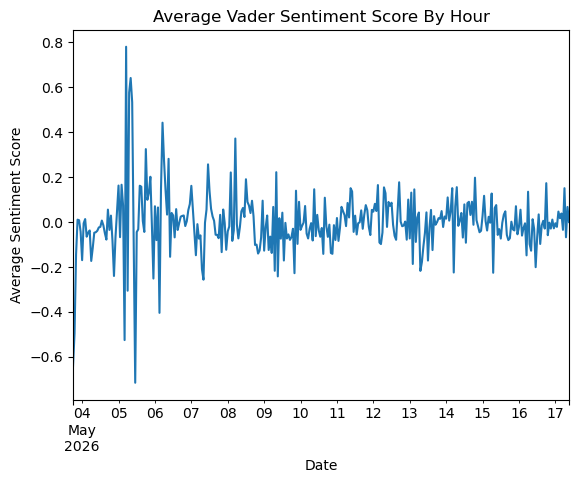

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

# Convert date column safely (handles mixed + timezone-aware formats)
series['date'] = pd.to_datetime(
    series['date'],
    errors='coerce',
    utc=True
)

# Optional: remove timezone (convert to naive datetime)
series['date'] = series['date'].dt.tz_convert(None)

# Set index for resampling
series.set_index('date', inplace=True)

# Ensure sentiment is numeric
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

# Resample hourly and compute mean sentiment
newSeries = series.resample('1H').mean()

# Plot
newSeries.plot(legend=False)

plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

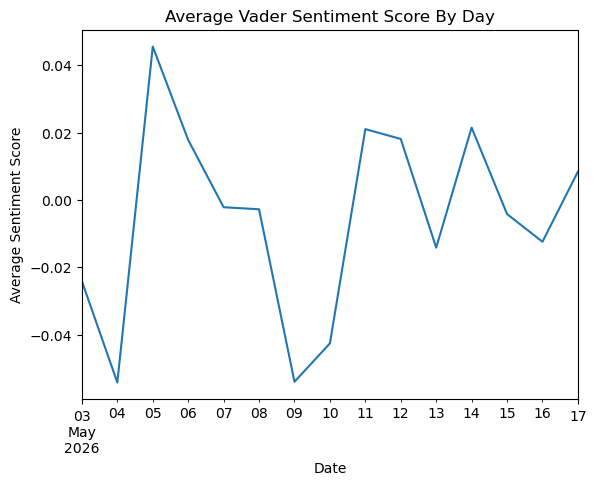

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

# Convert date column safely (handles mixed + timezone-aware formats)
series['date'] = pd.to_datetime(
    series['date'],
    errors='coerce',
    utc=True
)

# Optional: remove timezone (convert to naive datetime)
series['date'] = series['date'].dt.tz_convert(None)

# Set index for resampling
series.set_index('date', inplace=True)

# Ensure sentiment is numeric
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

# Resample hourly and compute mean sentiment
newSeries = series.resample('1D').mean()

# Plot
newSeries.plot(legend=False)

plt.title("Average Vader Sentiment Score By Day")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

/var/folders/rt/ntympq6n43582kgy0p0xxpc00000gn/T/ipykernel_92838/3528972904.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  newSeries = series.resample('1H').mean()


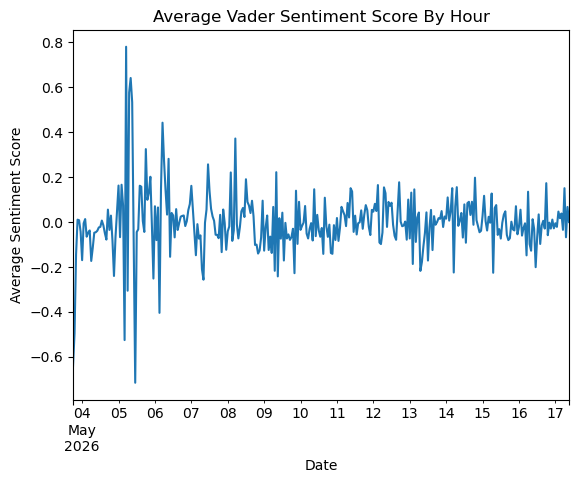

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

# Convert date column safely (handles mixed + timezone-aware formats)
series['date'] = pd.to_datetime(
    series['date'],
    errors='coerce',
    utc=True
)

# Optional: remove timezone (convert to naive datetime)
series['date'] = series['date'].dt.tz_convert(None)

# Set index for resampling
series.set_index('date', inplace=True)

# Ensure sentiment is numeric
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

# Resample hourly and compute mean sentiment
newSeries = series.resample('1H').mean()

# Plot
newSeries.plot(legend=False)

plt.title("Average Vader Sentiment Score By Hour")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

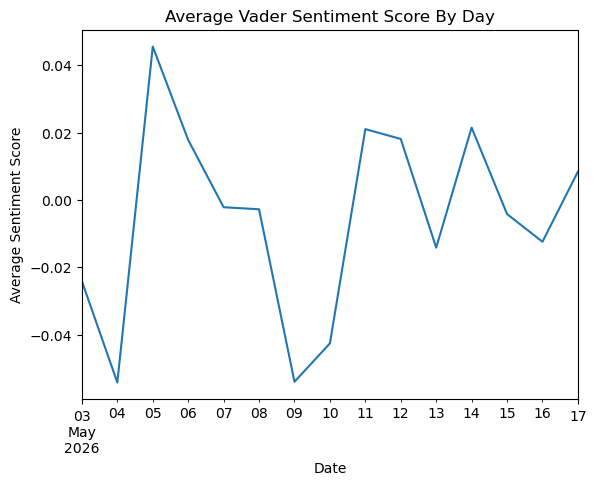

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Create DataFrame
series = pd.DataFrame(lSentimentVDR, columns=['date', 'sentiment'])

# Convert date column safely (handles mixed + timezone-aware formats)
series['date'] = pd.to_datetime(
    series['date'],
    errors='coerce',
    utc=True
)

# Optional: remove timezone (convert to naive datetime)
series['date'] = series['date'].dt.tz_convert(None)

# Set index for resampling
series.set_index('date', inplace=True)

# Ensure sentiment is numeric
series['sentiment'] = pd.to_numeric(series['sentiment'], errors='coerce')

# Resample hourly and compute mean sentiment
newSeries = series.resample('1D').mean()

# Plot
newSeries.plot(legend=False)

plt.title("Average Vader Sentiment Score By Day")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.show()

---
## Topic Analysis

In [26]:
#Code Adapted from https://datascienceplus.com/evaluation-of-topic-modeling-topic-coherence/
#Method to calculate the coherence scores for k number of topics 
def compute_coherence_values(dictionary, corpus, texts, start=2, limit=10, step=1):
    coherence_values = [] #List to store the coherence scores
    models = [] #List of models
    #Use a seed to ensure reproducability over multiple runs 
    SEED = 42
    random.seed(SEED)
    np.random.seed(SEED)

    #Train an LDA MODEL for k number of topics between the start and stop value
    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10
        )
        models.append(model)

        #Calculate the coherence score for each model
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )

        #Append cohenerence values to the list - to be used in plot
        coherence_values.append(coherencemodel.get_coherence())

    return models, coherence_values

In [27]:
#code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Create a dictionary mapping words to unique IDs from tokenized comments
dictionary = corpora.Dictionary(SB_token_comments)
#Convert tokenized documents into bag of words (BOW) representation
corpus = [dictionary.doc2bow(doc) for doc in SB_token_comments]

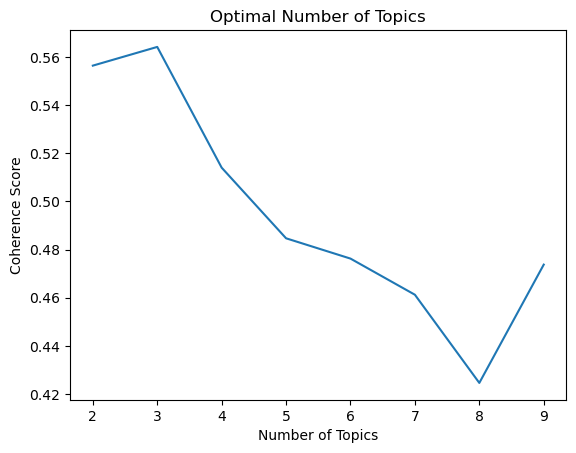

In [28]:
#Code adapted from: https://datascienceplus.com/evaluation-of-topic-modeling-topic-coherence/
#Run the method from above to calculate the coherence score of the LDA model for different k number of topics
#This code section may be slow to run.
models, coherence_values = compute_coherence_values(
    dictionary=dictionary,
    corpus=corpus,
    texts=SB_token_comments,
    start=2,
    limit=10,
    step=1)

#Plot the coherence scores for k number of topics.
x = range(2, 10)
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Optimal Number of Topics")
plt.show()

In [29]:
#Code adapted from: https://medium.com/@pinakdatta/understanding-lda-unveiling-hidden-topics-in-text-data-9bbbd25ae162
#Train the LDA model with the optimal number of topics
lda_model = LdaModel(corpus, num_topics=3, id2word=dictionary,random_state=42, passes = 5)
#Print the topics
print(lda_model.print_topics())

[(0, '0.016*"hantavirus" + 0.014*"like" + 0.014*"virus" + 0.013*"spread" + 0.010*"human" + 0.010*"rodent" + 0.008*"know" + 0.008*"one" + 0.008*"covid" + 0.007*"person"'), (1, '0.013*"go" + 0.010*"trump" + 0.008*"health" + 0.008*"get" + 0.008*"think" + 0.007*"us" + 0.007*"rfk" + 0.006*"good" + 0.006*"cdc" + 0.006*"public"'), (2, '0.048*"ship" + 0.046*"cruise" + 0.031*"hantavirus" + 0.025*"outbreak" + 0.018*"people" + 0.014*"passenger" + 0.012*"three" + 0.010*"die" + 0.008*"say" + 0.008*"suspected"')]


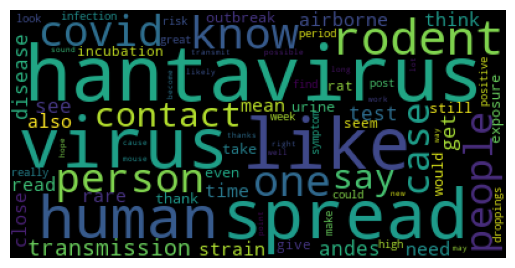

In [30]:
#Code adapted from: https://stackoverflow.com/questions/60993778/how-to-create-wordcloud-from-lda-model
#Create a word cloud for topic 0 - include top 75 words in topic
plt.imshow(WordCloud(random_state=42).fit_words(dict(lda_model.show_topic(0, 75))))
plt.axis("off")
plt.show() #Print the word cloud 

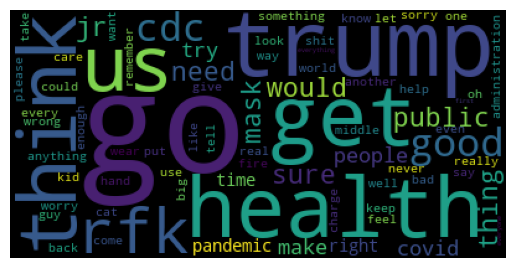

In [31]:
#Code adapted from: https://stackoverflow.com/questions/60993778/how-to-create-wordcloud-from-lda-model
#Create a word cloud for topic 1 - include top 75 words in topic
plt.imshow(WordCloud(random_state=42).fit_words(dict(lda_model.show_topic(1, 75))))
plt.axis("off")
plt.show() #Print the word cloud 

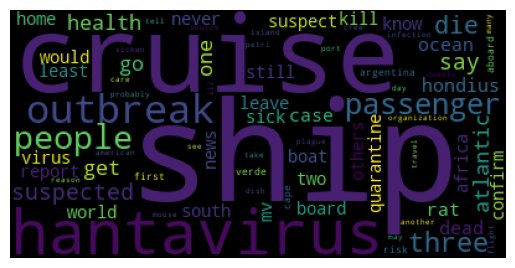

In [32]:
#Code adapted from: https://stackoverflow.com/questions/60993778/how-to-create-wordcloud-from-lda-model
#Create a word cloud for topic 1 - include top 75 words in topic
plt.imshow(WordCloud(random_state=42).fit_words(dict(lda_model.show_topic(2, 75))))
plt.axis("off")
plt.show() #Print the word cloud 

In [33]:
#Additonal topic analysis (word graph/plots and embedding mappings)